# 02 — Doublet detection (DoubletFinder)
Run per sample, as in the paper's Methods. Paper does not report DoubletFinder parameters;
choices below are documented defaults.

## Step 8.1 — Setup and load filtered objects

In [1]:
suppressPackageStartupMessages({
  library(Seurat); library(DoubletFinder); library(tidyverse)
})
proj <- "/mnt/d/project3_IFN-I"
set.seed(42)
objs <- readRDS(file.path(proj, "results/objects/01_objs_filtered.rds"))
map_int(objs, ncol)

HD1   HD2    P1    P2    P3    P4    P5    P6    P7    P8 
 7493 11744  9915 13838 12660 10269  2820  9654  9282  9467

In [ ]:
## Step 8.2 — Define the DoubletFinder function

In [2]:
run_doubletfinder <- function(obj, pcs = 1:20, rate_per_1000 = 0.008) {
  obj <- obj |>
    NormalizeData(verbose = FALSE) |>
    FindVariableFeatures(verbose = FALSE) |>
    ScaleData(verbose = FALSE) |>
    RunPCA(verbose = FALSE) |>
    FindNeighbors(dims = pcs, verbose = FALSE) |>
    FindClusters(resolution = 0.3, verbose = FALSE)

  sweep <- paramSweep(obj, PCs = pcs, sct = FALSE)
  bcmvn <- find.pK(summarizeSweep(sweep, GT = FALSE))
  pK <- as.numeric(as.character(bcmvn$pK[which.max(bcmvn$BCmetric)]))

  n_cells   <- ncol(obj)
  n_exp     <- round(rate_per_1000 * (n_cells / 1000) * n_cells)
  n_exp_adj <- round(n_exp * (1 - modelHomotypic(obj$seurat_clusters)))

  obj <- doubletFinder(obj, PCs = pcs, pN = 0.25, pK = pK,
                       nExp = n_exp_adj, sct = FALSE)

  df_col <- grep("^DF.classifications", colnames(obj@meta.data), value = TRUE)
  obj$doublet <- obj@meta.data[[df_col]]
  obj$df_pK   <- pK
  obj
}

## Step 8.3 — Run on each sample

2026-09-27 17:34:50.498674 — running HD1 (7493 cells)



[1] "Creating artificial doublets for pN = 5%"
[1] "Creating Seurat object..."
[1] "Normalizing Seurat object..."


Normalizing layer: counts



[1] "Finding variable genes..."


Finding variable features for layer counts



...

[1] "Finding variable genes..."


Finding variable features for layer counts



[1] "Scaling data..."


Centering and scaling data matrix



[1] "Running PCA..."
[1] "Calculating PC distance matrix..."
[1] "Defining neighborhoods..."
[1] "Computing pANN across all pK..."
[1] "pK = 0.001..."
[1] "pK = 0.005..."
[1] "pK = 0.01..."
[1] "pK = 0.02..."
[1] "pK = 0.03..."
[1] "pK = 0.04..."
[1] "pK = 0.05..."
[1] "pK = 0.06..."
[1] "pK = 0.07..."
[1] "pK = 0.08..."
[1] "pK = 0.09..."
[1] "pK = 0.1..."
[1] "pK = 0.11..."
[1] "pK = 0.12..."
[1] "pK = 0.13..."
[1] "pK = 0.14..."
[1] "pK = 0.15..."
[1] "pK = 0.16..."
[1] "pK = 0.17..."
[1] "pK = 0.18..."
[1] "pK = 0.19..."
[1] "pK = 0.2..."
[1] "pK = 0.21..."
[1] "pK = 0.22..."
[1] "pK = 0.23..."
[1] "pK = 0.24..."
[1] "pK = 0.25..."
[1] "pK = 0.26..."
[1] "pK = 0.27..."
[1] "pK = 0.28..."
[1] "pK = 0.29..."
[1] "pK = 0.3..."


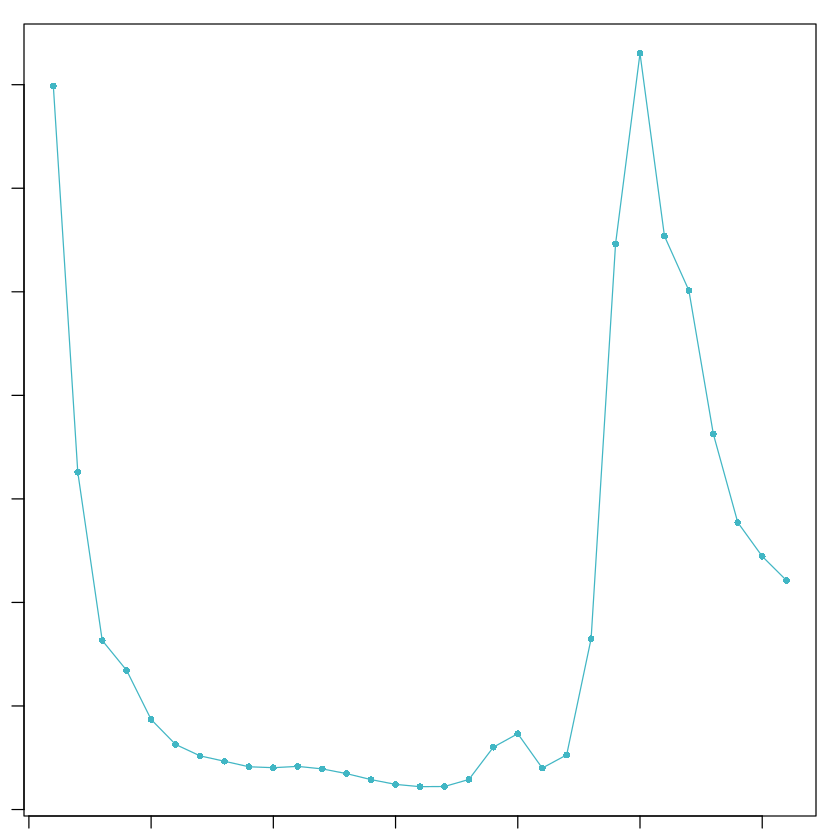

NULL
[1] "Creating 3915 artificial doublets..."
[1] "Creating Seurat object..."
[1] "Normalizing Seurat object..."


Normalizing layer: counts



[1] "Finding variable genes..."


Finding variable features for layer counts



[1] "Scaling data..."


...

[1] "Finding variable genes..."


Finding variable features for layer counts



[1] "Scaling data..."


Centering and scaling data matrix



[1] "Running PCA..."
[1] "Calculating PC distance matrix..."
[1] "Defining neighborhoods..."
[1] "Computing pANN across all pK..."
[1] "pK = 0.001..."
[1] "pK = 0.005..."
[1] "pK = 0.01..."
[1] "pK = 0.02..."
[1] "pK = 0.03..."
[1] "pK = 0.04..."
[1] "pK = 0.05..."
[1] "pK = 0.06..."
[1] "pK = 0.07..."
[1] "pK = 0.08..."
[1] "pK = 0.09..."
[1] "pK = 0.1..."
[1] "pK = 0.11..."
[1] "pK = 0.12..."
[1] "pK = 0.13..."
[1] "pK = 0.14..."
[1] "pK = 0.15..."
[1] "pK = 0.16..."
[1] "pK = 0.17..."
[1] "pK = 0.18..."
[1] "pK = 0.19..."
[1] "pK = 0.2..."
[1] "pK = 0.21..."
[1] "pK = 0.22..."
[1] "pK = 0.23..."
[1] "pK = 0.24..."
[1] "pK = 0.25..."
[1] "pK = 0.26..."
[1] "pK = 0.27..."
[1] "pK = 0.28..."
[1] "pK = 0.29..."
[1] "pK = 0.3..."


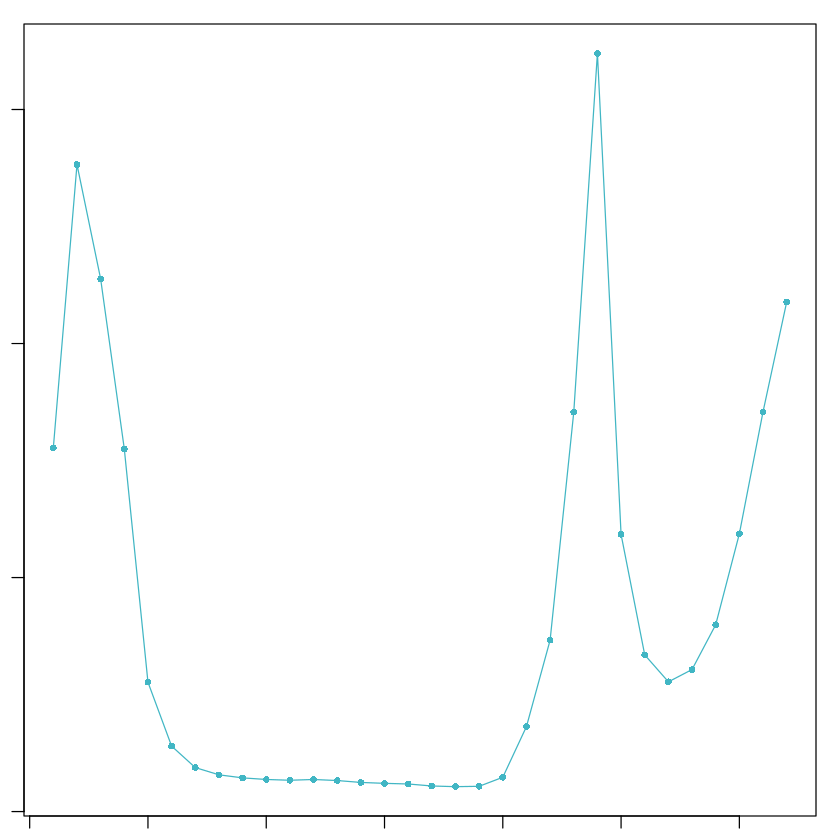

NULL
[1] "Creating 3305 artificial doublets..."
[1] "Creating Seurat object..."
[1] "Normalizing Seurat object..."


Normalizing layer: counts



[1] "Finding variable genes..."


Finding variable features for layer counts



[1] "Scaling data..."


...

[1] "Finding variable genes..."


Finding variable features for layer counts



[1] "Scaling data..."


Centering and scaling data matrix



[1] "Running PCA..."
[1] "Calculating PC distance matrix..."
[1] "Defining neighborhoods..."
[1] "Computing pANN across all pK..."
[1] "pK = 0.001..."
[1] "pK = 0.005..."
[1] "pK = 0.01..."
[1] "pK = 0.02..."
[1] "pK = 0.03..."
[1] "pK = 0.04..."
[1] "pK = 0.05..."
[1] "pK = 0.06..."
[1] "pK = 0.07..."
[1] "pK = 0.08..."
[1] "pK = 0.09..."
[1] "pK = 0.1..."
[1] "pK = 0.11..."
[1] "pK = 0.12..."
[1] "pK = 0.13..."
[1] "pK = 0.14..."
[1] "pK = 0.15..."
[1] "pK = 0.16..."
[1] "pK = 0.17..."
[1] "pK = 0.18..."
[1] "pK = 0.19..."
[1] "pK = 0.2..."
[1] "pK = 0.21..."
[1] "pK = 0.22..."
[1] "pK = 0.23..."
[1] "pK = 0.24..."
[1] "pK = 0.25..."
[1] "pK = 0.26..."
[1] "pK = 0.27..."
[1] "pK = 0.28..."
[1] "pK = 0.29..."
[1] "pK = 0.3..."


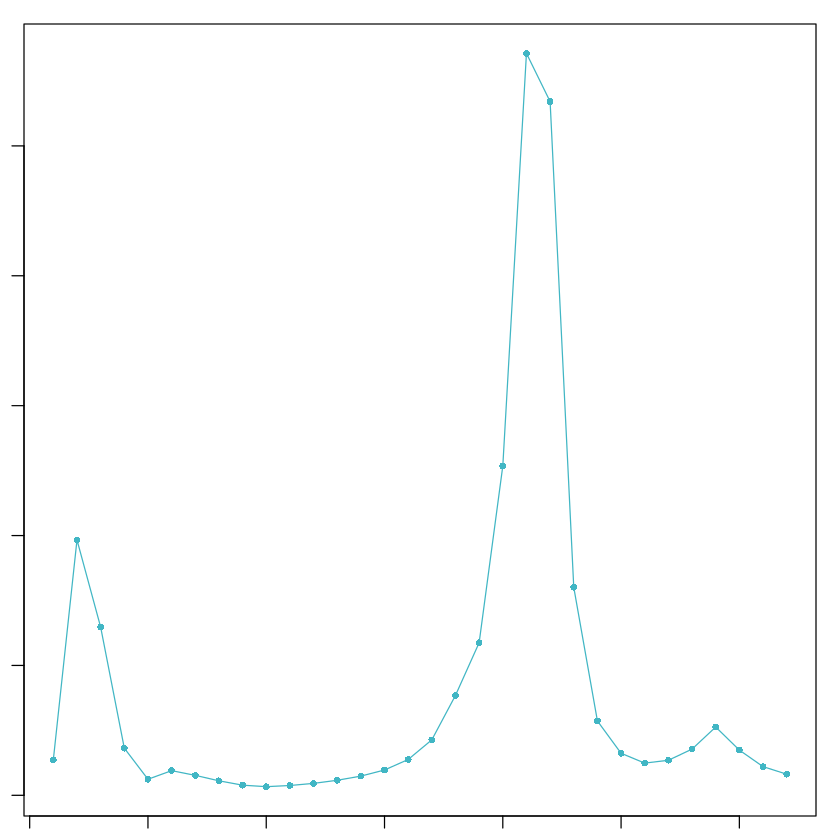

NULL
[1] "Creating 4613 artificial doublets..."
[1] "Creating Seurat object..."
[1] "Normalizing Seurat object..."


Normalizing layer: counts



[1] "Finding variable genes..."


Finding variable features for layer counts



[1] "Scaling data..."


...

[1] "Finding variable genes..."


Finding variable features for layer counts



[1] "Scaling data..."


Centering and scaling data matrix



[1] "Running PCA..."
[1] "Calculating PC distance matrix..."
[1] "Defining neighborhoods..."
[1] "Computing pANN across all pK..."
[1] "pK = 0.001..."
[1] "pK = 0.005..."
[1] "pK = 0.01..."
[1] "pK = 0.02..."
[1] "pK = 0.03..."
[1] "pK = 0.04..."
[1] "pK = 0.05..."
[1] "pK = 0.06..."
[1] "pK = 0.07..."
[1] "pK = 0.08..."
[1] "pK = 0.09..."
[1] "pK = 0.1..."
[1] "pK = 0.11..."
[1] "pK = 0.12..."
[1] "pK = 0.13..."
[1] "pK = 0.14..."
[1] "pK = 0.15..."
[1] "pK = 0.16..."
[1] "pK = 0.17..."
[1] "pK = 0.18..."
[1] "pK = 0.19..."
[1] "pK = 0.2..."
[1] "pK = 0.21..."
[1] "pK = 0.22..."
[1] "pK = 0.23..."
[1] "pK = 0.24..."
[1] "pK = 0.25..."
[1] "pK = 0.26..."
[1] "pK = 0.27..."
[1] "pK = 0.28..."
[1] "pK = 0.29..."
[1] "pK = 0.3..."


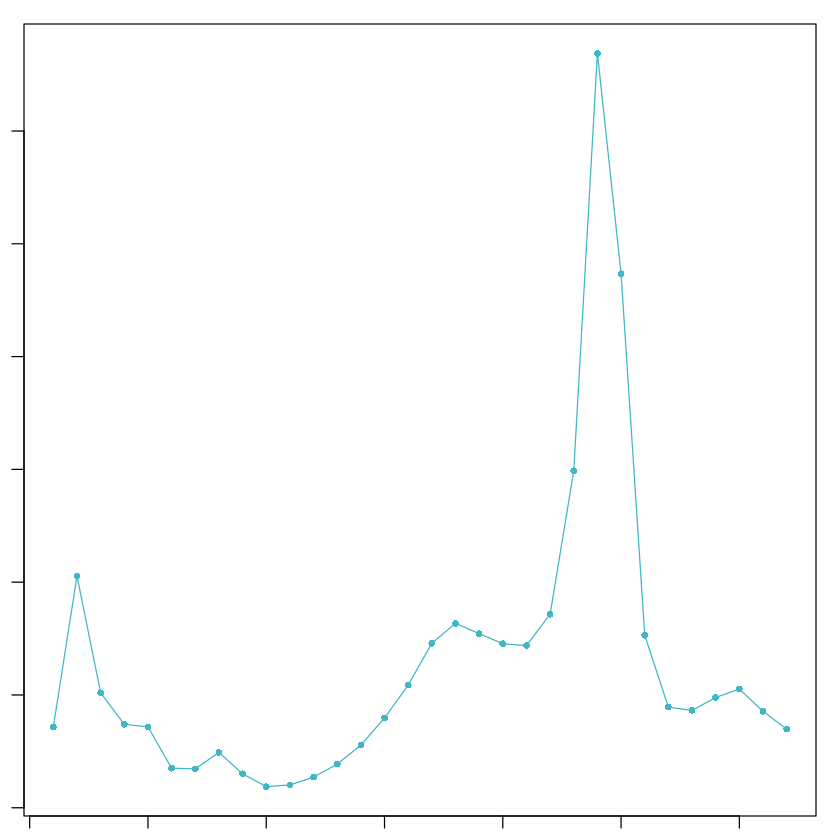

NULL
[1] "Creating 4220 artificial doublets..."
[1] "Creating Seurat object..."
[1] "Normalizing Seurat object..."


Normalizing layer: counts



[1] "Finding variable genes..."


Finding variable features for layer counts



[1] "Scaling data..."


...

[1] "Finding variable genes..."


Finding variable features for layer counts



[1] "Scaling data..."


Centering and scaling data matrix



[1] "Running PCA..."
[1] "Calculating PC distance matrix..."
[1] "Defining neighborhoods..."
[1] "Computing pANN across all pK..."
[1] "pK = 0.001..."
[1] "pK = 0.005..."
[1] "pK = 0.01..."
[1] "pK = 0.02..."
[1] "pK = 0.03..."
[1] "pK = 0.04..."
[1] "pK = 0.05..."
[1] "pK = 0.06..."
[1] "pK = 0.07..."
[1] "pK = 0.08..."
[1] "pK = 0.09..."
[1] "pK = 0.1..."
[1] "pK = 0.11..."
[1] "pK = 0.12..."
[1] "pK = 0.13..."
[1] "pK = 0.14..."
[1] "pK = 0.15..."
[1] "pK = 0.16..."
[1] "pK = 0.17..."
[1] "pK = 0.18..."
[1] "pK = 0.19..."
[1] "pK = 0.2..."
[1] "pK = 0.21..."
[1] "pK = 0.22..."
[1] "pK = 0.23..."
[1] "pK = 0.24..."
[1] "pK = 0.25..."
[1] "pK = 0.26..."
[1] "pK = 0.27..."
[1] "pK = 0.28..."
[1] "pK = 0.29..."
[1] "pK = 0.3..."


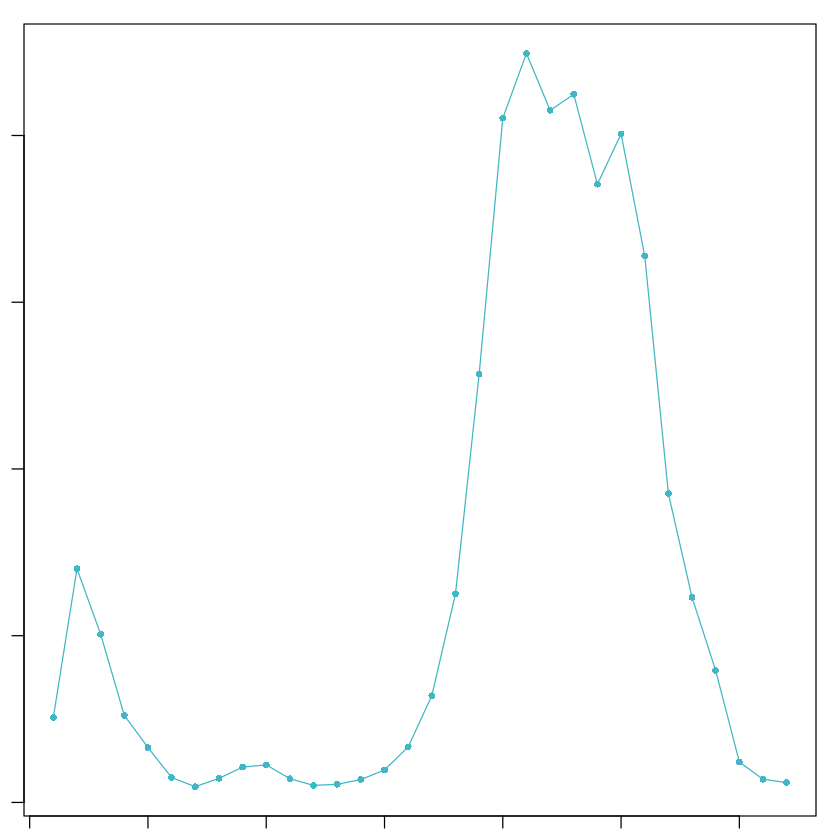

NULL
[1] "Creating 3423 artificial doublets..."
[1] "Creating Seurat object..."
[1] "Normalizing Seurat object..."


Normalizing layer: counts



[1] "Finding variable genes..."


Finding variable features for layer counts



[1] "Scaling data..."


...

[1] "Finding variable genes..."


Finding variable features for layer counts



[1] "Scaling data..."


Centering and scaling data matrix



[1] "Running PCA..."
[1] "Calculating PC distance matrix..."
[1] "Defining neighborhoods..."
[1] "Computing pANN across all pK..."
[1] "pK = 0.005..."
[1] "pK = 0.01..."
[1] "pK = 0.02..."
[1] "pK = 0.03..."
[1] "pK = 0.04..."
[1] "pK = 0.05..."
[1] "pK = 0.06..."
[1] "pK = 0.07..."
[1] "pK = 0.08..."
[1] "pK = 0.09..."
[1] "pK = 0.1..."
[1] "pK = 0.11..."
[1] "pK = 0.12..."
[1] "pK = 0.13..."
[1] "pK = 0.14..."
[1] "pK = 0.15..."
[1] "pK = 0.16..."
[1] "pK = 0.17..."
[1] "pK = 0.18..."
[1] "pK = 0.19..."
[1] "pK = 0.2..."
[1] "pK = 0.21..."
[1] "pK = 0.22..."
[1] "pK = 0.23..."
[1] "pK = 0.24..."
[1] "pK = 0.25..."
[1] "pK = 0.26..."
[1] "pK = 0.27..."
[1] "pK = 0.28..."
[1] "pK = 0.29..."
[1] "pK = 0.3..."


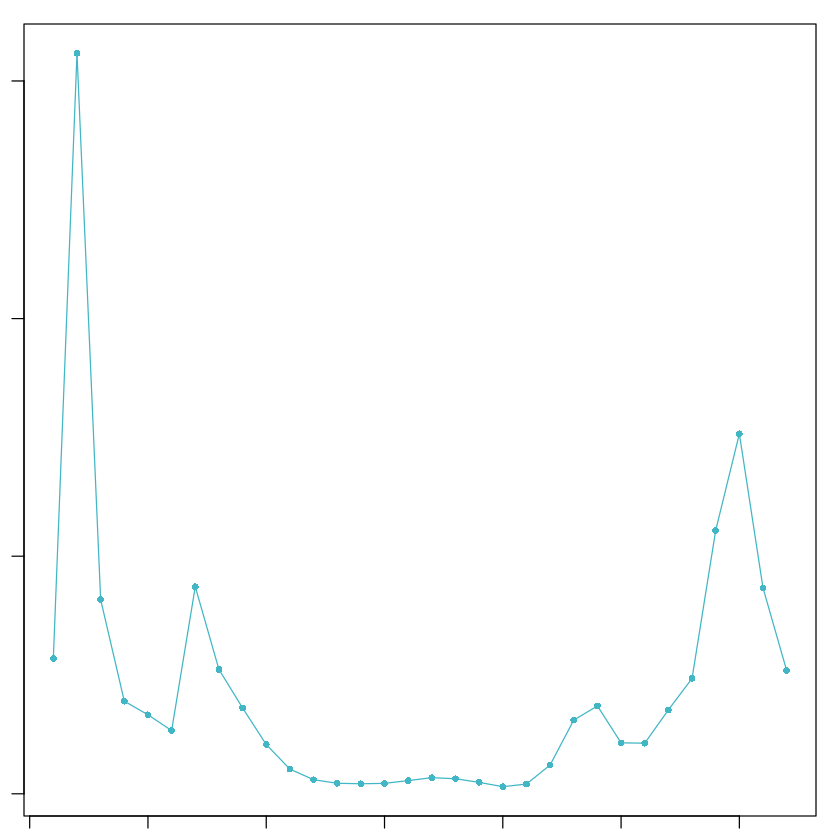

NULL
[1] "Creating 940 artificial doublets..."
[1] "Creating Seurat object..."
[1] "Normalizing Seurat object..."


Normalizing layer: counts



[1] "Finding variable genes..."


Finding variable features for layer counts



[1] "Scaling data..."


...

[1] "Finding variable genes..."


Finding variable features for layer counts



[1] "Scaling data..."


Centering and scaling data matrix



[1] "Running PCA..."
[1] "Calculating PC distance matrix..."
[1] "Defining neighborhoods..."
[1] "Computing pANN across all pK..."
[1] "pK = 0.001..."
[1] "pK = 0.005..."
[1] "pK = 0.01..."
[1] "pK = 0.02..."
[1] "pK = 0.03..."
[1] "pK = 0.04..."
[1] "pK = 0.05..."
[1] "pK = 0.06..."
[1] "pK = 0.07..."
[1] "pK = 0.08..."
[1] "pK = 0.09..."
[1] "pK = 0.1..."
[1] "pK = 0.11..."
[1] "pK = 0.12..."
[1] "pK = 0.13..."
[1] "pK = 0.14..."
[1] "pK = 0.15..."
[1] "pK = 0.16..."
[1] "pK = 0.17..."
[1] "pK = 0.18..."
[1] "pK = 0.19..."
[1] "pK = 0.2..."
[1] "pK = 0.21..."
[1] "pK = 0.22..."
[1] "pK = 0.23..."
[1] "pK = 0.24..."
[1] "pK = 0.25..."
[1] "pK = 0.26..."
[1] "pK = 0.27..."
[1] "pK = 0.28..."
[1] "pK = 0.29..."
[1] "pK = 0.3..."


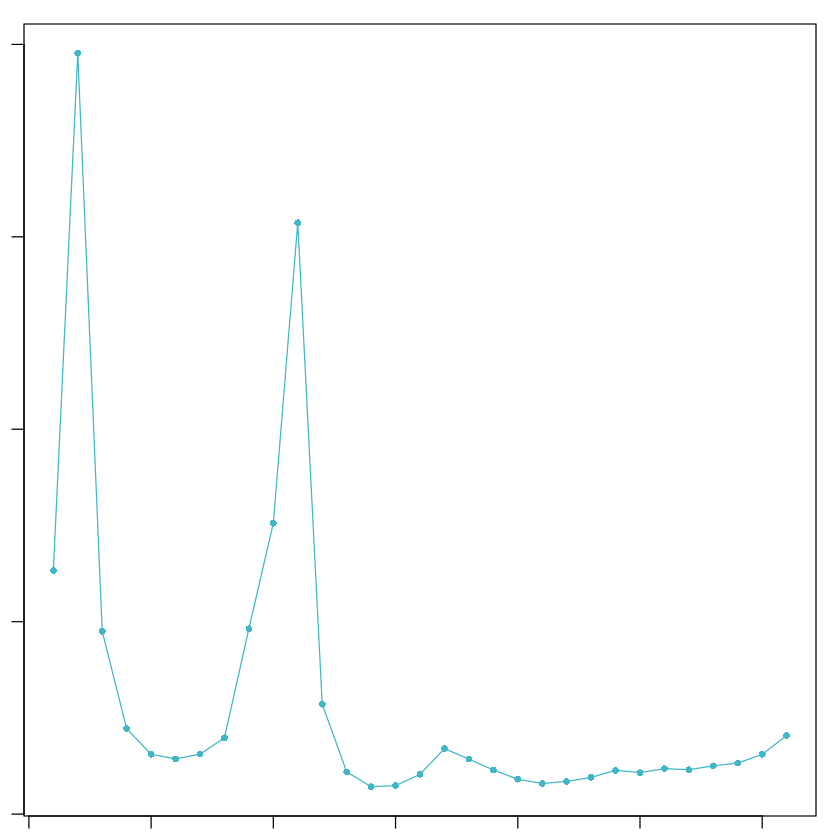

NULL
[1] "Creating 3218 artificial doublets..."
[1] "Creating Seurat object..."
[1] "Normalizing Seurat object..."


Normalizing layer: counts



[1] "Finding variable genes..."


Finding variable features for layer counts



[1] "Scaling data..."


...

[1] "Finding variable genes..."


Finding variable features for layer counts



[1] "Scaling data..."


Centering and scaling data matrix



[1] "Running PCA..."
[1] "Calculating PC distance matrix..."
[1] "Defining neighborhoods..."
[1] "Computing pANN across all pK..."
[1] "pK = 0.005..."
[1] "pK = 0.01..."
[1] "pK = 0.02..."
[1] "pK = 0.03..."
[1] "pK = 0.04..."
[1] "pK = 0.05..."
[1] "pK = 0.06..."
[1] "pK = 0.07..."
[1] "pK = 0.08..."
[1] "pK = 0.09..."
[1] "pK = 0.1..."
[1] "pK = 0.11..."
[1] "pK = 0.12..."
[1] "pK = 0.13..."
[1] "pK = 0.14..."
[1] "pK = 0.15..."
[1] "pK = 0.16..."
[1] "pK = 0.17..."
[1] "pK = 0.18..."
[1] "pK = 0.19..."
[1] "pK = 0.2..."
[1] "pK = 0.21..."
[1] "pK = 0.22..."
[1] "pK = 0.23..."
[1] "pK = 0.24..."
[1] "pK = 0.25..."
[1] "pK = 0.26..."
[1] "pK = 0.27..."
[1] "pK = 0.28..."
[1] "pK = 0.29..."
[1] "pK = 0.3..."


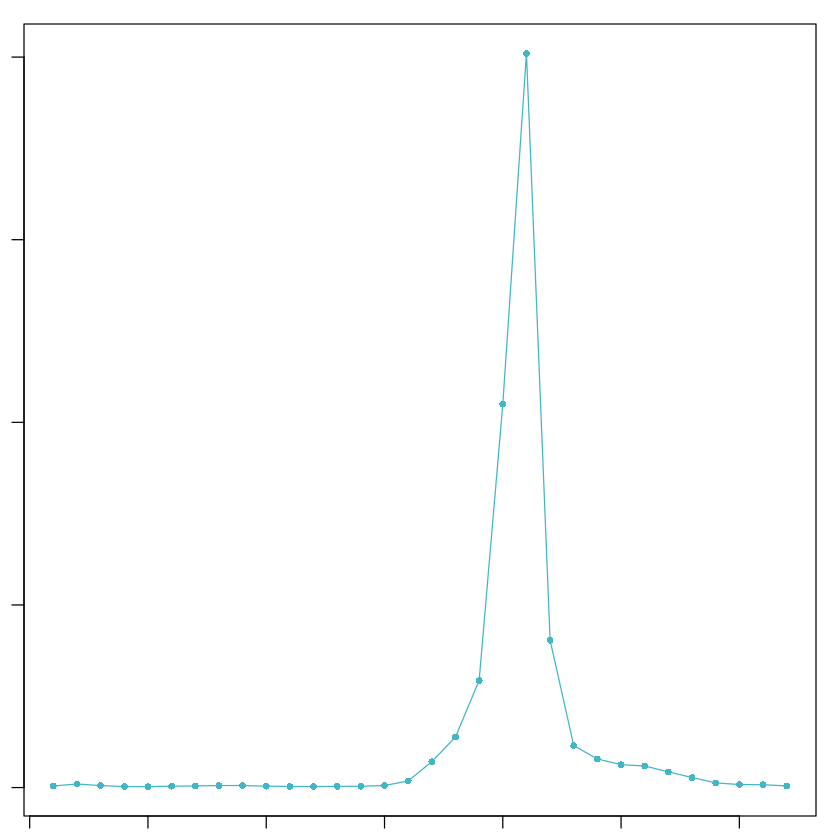

NULL
[1] "Creating 3094 artificial doublets..."
[1] "Creating Seurat object..."
[1] "Normalizing Seurat object..."


Normalizing layer: counts



[1] "Finding variable genes..."


Finding variable features for layer counts



[1] "Scaling data..."


...

[1] "Finding variable genes..."


Finding variable features for layer counts



[1] "Scaling data..."


Centering and scaling data matrix



[1] "Running PCA..."
[1] "Calculating PC distance matrix..."
[1] "Defining neighborhoods..."
[1] "Computing pANN across all pK..."
[1] "pK = 0.005..."
[1] "pK = 0.01..."
[1] "pK = 0.02..."
[1] "pK = 0.03..."
[1] "pK = 0.04..."
[1] "pK = 0.05..."
[1] "pK = 0.06..."
[1] "pK = 0.07..."
[1] "pK = 0.08..."
[1] "pK = 0.09..."
[1] "pK = 0.1..."
[1] "pK = 0.11..."
[1] "pK = 0.12..."
[1] "pK = 0.13..."
[1] "pK = 0.14..."
[1] "pK = 0.15..."
[1] "pK = 0.16..."
[1] "pK = 0.17..."
[1] "pK = 0.18..."
[1] "pK = 0.19..."
[1] "pK = 0.2..."
[1] "pK = 0.21..."
[1] "pK = 0.22..."
[1] "pK = 0.23..."
[1] "pK = 0.24..."
[1] "pK = 0.25..."
[1] "pK = 0.26..."
[1] "pK = 0.27..."
[1] "pK = 0.28..."
[1] "pK = 0.29..."
[1] "pK = 0.3..."


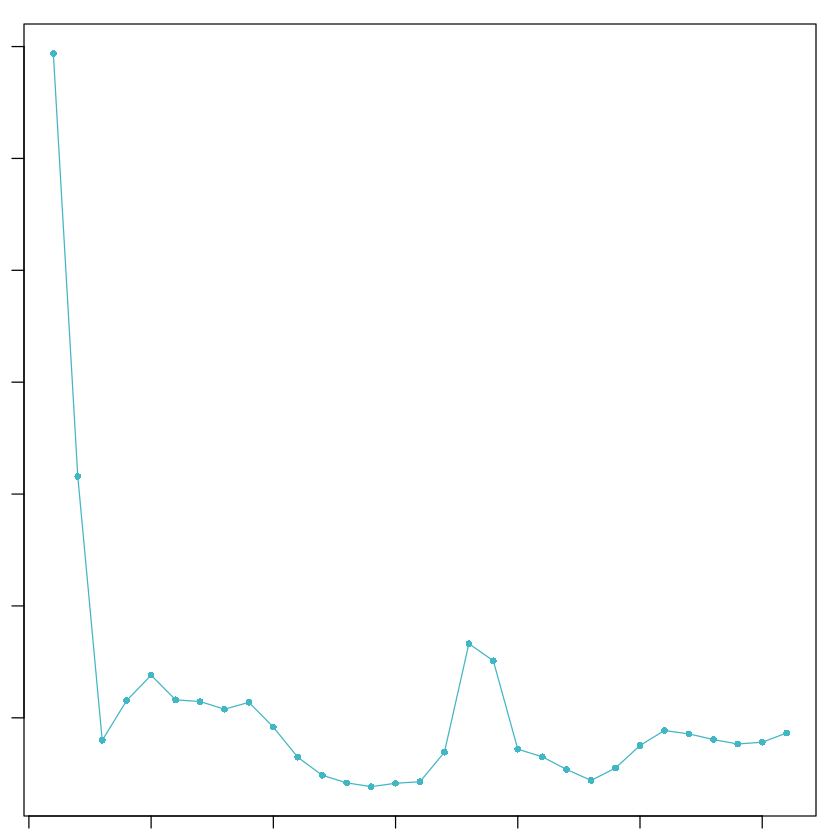

NULL
[1] "Creating 3156 artificial doublets..."
[1] "Creating Seurat object..."
[1] "Normalizing Seurat object..."


Normalizing layer: counts



[1] "Finding variable genes..."


Finding variable features for layer counts



[1] "Scaling data..."


Centering and scaling data matrix



[1] "Running PCA..."
[1] "Calculating PC distance matrix..."
[1] "Computing pANN..."
[1] "Classifying doublets.."


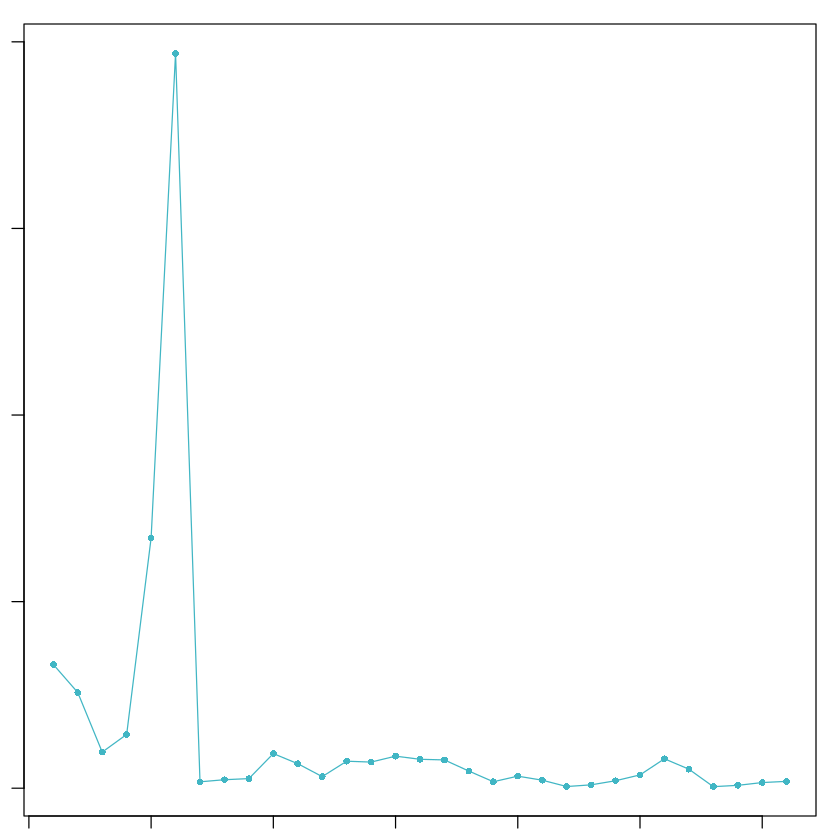

In [3]:
objs_df <- imap(objs, function(obj, s) {
  message(Sys.time(), " — running ", s, " (", ncol(obj), " cells)")
  run_doubletfinder(obj)
})

## Step 8.4 — Doublet summary per sample

In [4]:
df_summary <- imap_dfr(objs_df, ~ tibble(
  sample     = .y,
  cells      = ncol(.x),
  pK         = unique(.x$df_pK),
  doublets   = sum(.x$doublet == "Doublet"),
  pct_doublet = round(100 * mean(.x$doublet == "Doublet"), 1)))
df_summary
write_csv(df_summary, file.path(proj, "results/tables/02_doublet_summary.csv"))

sample,cells,pK,doublets,pct_doublet
<chr>,<dbl>,<dbl>,<int>,<dbl>
HD1,7493,0.240,372,5.0
HD2,11744,0.220,824,7.0
P1,9915,0.190,631,6.4
P2,13838,0.220,1326,9.6
P3,12660,0.190,978,7.7
P4,10269,0.005,644,6.3
P5,2820,0.010,55,2.0
P6,9654,0.190,599,6.2
P7,9282,0.005,589,6.3


## Step 8.5 — Sanity check: do doublets have more RNA than singlets?

In [5]:
dbl_check <- imap_dfr(objs_df, function(obj, s) {
  md <- obj@meta.data
  sing <- md$doublet == "Singlet"
  tibble(sample      = s,
         pK          = unique(obj$df_pK),
         umi_singlet = median(md$nCount_RNA[sing]),
         umi_doublet = median(md$nCount_RNA[!sing]),
         umi_ratio   = round(umi_doublet / umi_singlet, 2),
         gene_ratio  = round(median(md$nFeature_RNA[!sing]) /
                             median(md$nFeature_RNA[sing]), 2))
})
dbl_check
write_csv(dbl_check, file.path(proj, "results/tables/02_doublet_plausibility.csv"))

sample,pK,umi_singlet,umi_doublet,umi_ratio,gene_ratio
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HD1,0.240,4326.0,9470.0,2.19,1.71
HD2,0.220,4082.0,8870.0,2.17,1.62
P1,0.190,5126.0,10270.0,2.00,1.63
P2,0.220,3962.0,7516.5,1.90,1.52
P3,0.190,4259.5,7870.5,1.85,1.58
P4,0.005,4496.0,9460.5,2.10,1.68
P5,0.010,2571.0,5128.0,1.99,1.74
P6,0.190,3391.0,7540.0,2.22,1.75
P7,0.005,3928.0,8672.0,2.21,1.74


## Step 8.6 — Save doublet calls for the record

In [6]:
dbl_calls <- imap_dfr(objs_df, ~ tibble(
  barcode = colnames(.x),
  sample  = .y,
  doublet = .x$doublet,
  pANN    = .x@meta.data[[grep("^pANN", colnames(.x@meta.data), value = TRUE)]]))
write_csv(dbl_calls, file.path(proj, "results/tables/02_doublet_calls.csv"))

## Step 8.7 — Remove doublets, slim objects, and save

In [7]:
objs_clean <- map(objs_df, function(obj) {
  obj <- subset(obj, subset = doublet == "Singlet")
  DietSeurat(obj, layers = "counts", dimreducs = NULL, graphs = NULL)
})
map_int(objs_clean, ncol)
saveRDS(objs_clean, file.path(proj, "results/objects/02_objs_singlets.rds"))

HD1   HD2    P1    P2    P3    P4    P5    P6    P7    P8 
 7121 10920  9284 12512 11682  9625  2765  9055  8693  8845

### Doublet detection notes
- DoubletFinder per sample, PCs 1–20, pN = 0.25, pK chosen by max BCmetric,
  expected rate 0.8% per 1,000 cells, adjusted for homotypic doublets.
- Doublet % (2.0–9.6%) is set by the assumed rate, not estimated from the data;
  it scales with sample size (P5 lowest, P2 highest).
- Chosen pK split into high (0.19–0.24; 6 samples) and low (0.005–0.05; P4, P5, P7, P8) values.
- Plausibility check: doublets have ~2x the UMIs (ratio 1.85–2.24) and 1.5–1.8x the genes
  of singlets in every sample, regardless of pK -> calls accepted.